# Treinamento ResNet50 com PyTorch + GPU — v2 fine-tuning layer2_3_4

Notebook experimental separado para testar a ResNet50 com fine-tuning mais profundo, ajustando `layer2 + layer3 + layer4 + fc`.

Este arquivo não substitui o notebook oficial/final já usado na comparação principal.

In [1]:
# CÉLULA 02 - Importações e verificação de GPU

import os
# Reduz fragmentação de memória CUDA em testes com imagens maiores.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
CUDA disponível: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# CÉLULA 03 - Configurações gerais do experimento

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Configuração experimental v2 para testar fine-tuning mais profundo na ResNet50.
# Este notebook é separado para não alterar o arquivo oficial.
IMG_SIZE = (448, 448)
BATCH_SIZE = 12
NUM_CLASSES = 5

NUM_WORKERS = 8
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

EPOCHS_HEAD = 10
EPOCHS_FINE_TUNING = 40

HEAD_LEARNING_RATE = 1e-3
FINE_TUNING_LEARNING_RATE = 1e-5

DROPOUT_RATE = 0.3
PATIENCE = 6

# Pesos de classe suavizados. Esta foi a configuração mais estável na DenseNet121.
CLASS_WEIGHT_MODE = "sqrt"  # opções: "balanced", "sqrt", "none"

# Perda usada na configuração final.
LOSS_FUNCTION = "cross_entropy"  # opções: "cross_entropy", "focal"
FOCAL_GAMMA = 1.5
LABEL_SMOOTHING = 0.015

# Mantido desativado porque o sampler piorou o equilíbrio geral nos testes da DenseNet121.
USE_WEIGHTED_SAMPLER = False

# Escopo experimental mais profundo.
# layer2_3_4 ajusta layer2 + layer3 + layer4 + fc.
FINE_TUNING_SCOPE = "layer2_3_4"  # opções: "layer4", "layer3_4", "layer2_3_4"

MODEL_NAME = "ResNet50"
MODEL_KEY = "resnet50_pytorch_gpu"
EXPERIMENT_NAME = "resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5"
MODEL_OUTPUT_KEY = f"{MODEL_KEY}_{EXPERIMENT_NAME}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", device)
print("Configuração:", {
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_WORKERS": NUM_WORKERS,
    "CLASS_WEIGHT_MODE": CLASS_WEIGHT_MODE,
    "LOSS_FUNCTION": LOSS_FUNCTION,
    "LABEL_SMOOTHING": LABEL_SMOOTHING,
    "USE_WEIGHTED_SAMPLER": USE_WEIGHTED_SAMPLER,
    "FINE_TUNING_SCOPE": FINE_TUNING_SCOPE,
})


Dispositivo usado: cuda
Configuração: {'IMG_SIZE': (448, 448), 'BATCH_SIZE': 12, 'NUM_WORKERS': 8, 'CLASS_WEIGHT_MODE': 'sqrt', 'LOSS_FUNCTION': 'cross_entropy', 'LABEL_SMOOTHING': 0.015, 'USE_WEIGHTED_SAMPLER': False, 'FINE_TUNING_SCOPE': 'layer2_3_4'}


In [3]:
# CÉLULA 04 - Caminhos do projeto

cwd = Path.cwd().resolve()

# Funciona tanto se o notebook for executado da raiz do projeto quanto de dentro de notebooks/
if cwd.name == "notebooks":
    PROJECT_DIR = cwd.parent
else:
    PROJECT_DIR = cwd

SPLITS_DIR = PROJECT_DIR / "data" / "splits"
RAW_IMAGES_DIR = PROJECT_DIR / "data" / "raw" / "train_images"

RESULTS_DIR = PROJECT_DIR / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_OUTPUT_DIR = MODELS_DIR / MODEL_OUTPUT_KEY
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("SPLITS_DIR:", SPLITS_DIR)
print("RAW_IMAGES_DIR:", RAW_IMAGES_DIR)
print("MODEL_OUTPUT_DIR:", MODEL_OUTPUT_DIR)

PROJECT_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica
SPLITS_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/data/splits
RAW_IMAGES_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/data/raw/train_images
MODEL_OUTPUT_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5


In [4]:
# CÉLULA 05 - Carregar splits e corrigir caminhos

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
val_df = pd.read_csv(SPLITS_DIR / "val_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

def corrigir_caminhos(df):
    df = df.copy()
    df["image_path"] = df["id_code"].apply(
        lambda image_id: str((RAW_IMAGES_DIR / f"{image_id}.png").resolve())
    )
    return df

train_df = corrigir_caminhos(train_df)
val_df = corrigir_caminhos(val_df)
test_df = corrigir_caminhos(test_df)

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

train_df.head()

Treino: (2197, 3)
Validação: (732, 3)
Teste: (733, 3)


,id_code,diagnosis,image_path
0,9df31421cdd2,2,/home/avell/Documentos/Caio/tcc-retinopatia-di...
1,d3de0d313d61,1,/home/avell/Documentos/Caio/tcc-retinopatia-di...
2,bb85097857fa,0,/home/avell/Documentos/Caio/tcc-retinopatia-di...
3,abf09c44d5f4,2,/home/avell/Documentos/Caio/tcc-retinopatia-di...
4,187f6ccda87a,4,/home/avell/Documentos/Caio/tcc-retinopatia-di...


In [5]:
# CÉLULA 06 - Verificar imagens ausentes

def verificar_imagens(df, nome):
    missing = df[~df["image_path"].apply(lambda path: Path(path).exists())]
    print(f"{nome}:")
    print("Total:", len(df))
    print("Imagens ausentes:", len(missing))
    if len(missing) > 0:
        display(missing.head())
        raise FileNotFoundError(f"Existem imagens ausentes em {nome}.")

verificar_imagens(train_df, "Treino")
verificar_imagens(val_df, "Validação")
verificar_imagens(test_df, "Teste")

Treino:
Total: 2197
Imagens ausentes: 0
Validação:
Total: 732
Imagens ausentes: 0
Teste:
Total: 733
Imagens ausentes: 0


In [6]:
# CÉLULA 07 - Nomes das classes

class_names = {
    0: "Sem retinopatia",
    1: "Retinopatia leve",
    2: "Retinopatia moderada",
    3: "Retinopatia severa",
    4: "Retinopatia proliferativa",
}

class_labels = [class_names[i] for i in range(NUM_CLASSES)]

print(class_labels)

['Sem retinopatia', 'Retinopatia leve', 'Retinopatia moderada', 'Retinopatia severa', 'Retinopatia proliferativa']


In [7]:
# CÉLULA 08 - Transformações de treino, validação e teste

# Normalização padrão ImageNet, compatível com modelos pré-treinados do torchvision.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomRotation(degrees=8),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [8]:
# CÉLULA 09 - Dataset e DataLoader

class AptosDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        label = int(row["diagnosis"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = AptosDataset(train_df, transform=train_transform)
val_dataset = AptosDataset(val_df, transform=eval_transform)
test_dataset = AptosDataset(test_df, transform=eval_transform)

sampler = None

if USE_WEIGHTED_SAMPLER:
    train_labels = train_df["diagnosis"].astype(int).values
    class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
    class_sample_weights = 1.0 / class_counts

    sample_weights = np.array([
        class_sample_weights[label]
        for label in train_labels
    ])

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    print("WeightedRandomSampler ativado.")
    print("Contagem por classe:", class_counts)
else:
    print("WeightedRandomSampler desativado. Usando shuffle=True no treino.")

# Se sampler estiver ativo, não pode usar shuffle=True.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=(sampler is None),
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

images, labels = next(iter(train_loader))
print("Batch imagens:", images.shape)
print("Batch rótulos:", labels.shape)
print("Dtype imagens:", images.dtype)
print("Dtype rótulos:", labels.dtype)


WeightedRandomSampler desativado. Usando shuffle=True no treino.
Batch imagens: torch.Size([12, 3, 448, 448])
Batch rótulos: torch.Size([12])
Dtype imagens: torch.float32
Dtype rótulos: torch.int64


In [9]:
# CÉLULA 10 - Pesos por classe e função de perda

classes = np.unique(train_df["diagnosis"].values)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["diagnosis"].values
)

class_weights_balanced = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, class_weights_values)
}

class_weights_sqrt = {
    class_id: float(np.sqrt(weight))
    for class_id, weight in class_weights_balanced.items()
}

if CLASS_WEIGHT_MODE == "balanced":
    class_weights = class_weights_balanced
elif CLASS_WEIGHT_MODE == "sqrt":
    class_weights = class_weights_sqrt
elif CLASS_WEIGHT_MODE == "none":
    class_weights = None
else:
    raise ValueError("CLASS_WEIGHT_MODE deve ser 'balanced', 'sqrt' ou 'none'.")

print("Class weights balanceados:")
print(class_weights_balanced)

print("\nClass weights suavizados:")
print(class_weights_sqrt)

print("\nClass weights usados neste experimento:")
print(class_weights)

if class_weights is not None:
    weight_tensor = torch.tensor(
        [class_weights[i] for i in range(NUM_CLASSES)],
        dtype=torch.float32,
        device=device
    )
else:
    weight_tensor = None


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss

        return loss.mean()


if LOSS_FUNCTION == "cross_entropy":
    criterion = nn.CrossEntropyLoss(
        weight=weight_tensor,
        label_smoothing=LABEL_SMOOTHING
    )
elif LOSS_FUNCTION == "focal":
    criterion = FocalLoss(alpha=weight_tensor, gamma=FOCAL_GAMMA)
else:
    raise ValueError("LOSS_FUNCTION deve ser 'cross_entropy' ou 'focal'.")

print("\nFunção de perda usada:", LOSS_FUNCTION)
if LOSS_FUNCTION == "cross_entropy":
    print("Label smoothing:", LABEL_SMOOTHING)
if LOSS_FUNCTION == "focal":
    print("Focal gamma:", FOCAL_GAMMA)


Class weights balanceados:
{0: 0.405724838411819, 1: 1.9792792792792793, 2: 0.7335559265442404, 3: 3.787931034482759, 4: 2.4824858757062147}

Class weights suavizados:
{0: 0.6369653353298114, 1: 1.4068686076813568, 2: 0.8564787951515439, 3: 1.9462607827531127, 4: 1.5755906434433453}

Class weights usados neste experimento:
{0: 0.6369653353298114, 1: 1.4068686076813568, 2: 0.8564787951515439, 3: 1.9462607827531127, 4: 1.5755906434433453}

Função de perda usada: cross_entropy
Label smoothing: 0.015


In [10]:
# CÉLULA 11 - Criar modelo ResNet50 e treinar somente a cabeça inicialmente

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Congelar todas as camadas inicialmente.
for param in model.parameters():
    param.requires_grad = False

# Trocar a cabeça final.
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

# Apenas a cabeça treina na primeira etapa.
optimizer_head = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LEARNING_RATE
)

scheduler_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head,
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

print(model.fc)

# Teste de forward
model.eval()
with torch.no_grad():
    sample_images = images.to(device)
    preds = model(sample_images)
    print("Predições:", preds.shape)


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=5, bias=True)
)
Predições: torch.Size([12, 5])


In [11]:
# CÉLULA 12 - Funções de treino, validação, early stopping e avaliação

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(predicted.cpu().numpy().tolist())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


def fit_phase(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs,
    checkpoint_path,
    phase_name,
    patience=PATIENCE,
):
    history = []

    best_val_loss = float("inf")
    best_epoch = 0
    patience_counter = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "learning_rate": current_lr,
        }
        history.append(row)

        print(
            f"[{phase_name}] Época {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | lr={current_lr:.2e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  Melhor modelo salvo em: {checkpoint_path}")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping na fase {phase_name}. Melhor época: {best_epoch}")
            break

    phase_time = time.time() - start_time

    # Restaurar melhor checkpoint da fase.
    try:
        state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)

    return history, phase_time

In [12]:
# CÉLULA 13 - Treinar a cabeça do modelo

checkpoint_head_path = MODEL_OUTPUT_DIR / f"{MODEL_OUTPUT_KEY}_head_best.pt"

history_head, head_training_time = fit_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_head,
    scheduler=scheduler_head,
    device=device,
    epochs=EPOCHS_HEAD,
    checkpoint_path=checkpoint_head_path,
    phase_name="head",
)

print(f"Tempo de treinamento da cabeça: {head_training_time:.2f} segundos")

[head] Época 01/10 | train_loss=1.2323 train_acc=0.6673 | val_loss=1.0932 val_acc=0.7404 | lr=1.00e-03
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_head_best.pt
[head] Época 02/10 | train_loss=0.9966 train_acc=0.7365 | val_loss=1.0337 val_acc=0.7391 | lr=1.00e-03
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_head_best.pt
[head] Época 03/10 | train_loss=0.9322 train_acc=0.7592 | val_loss=0.9450 val_acc=0.7650 | lr=1.00e-03
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/resnet50_pyt

In [13]:
# CÉLULA 14 - Configurar fine-tuning

# Opções:
# - FINE_TUNING_SCOPE = "layer4": ajusta apenas layer4 + fc.
# - FINE_TUNING_SCOPE = "layer3_4": ajusta layer3 + layer4 + fc.
# - FINE_TUNING_SCOPE = "layer2_3_4": ajusta layer2 + layer3 + layer4 + fc.
#
# Neste experimento v2, o objetivo é testar um fine-tuning mais profundo
# do que o usado na ResNet50 final oficial.

for name, param in model.named_parameters():
    if FINE_TUNING_SCOPE == "layer4":
        param.requires_grad = (
            name.startswith("layer4")
            or name.startswith("fc")
        )
    elif FINE_TUNING_SCOPE == "layer3_4":
        param.requires_grad = (
            name.startswith("layer3")
            or name.startswith("layer4")
            or name.startswith("fc")
        )
    elif FINE_TUNING_SCOPE == "layer2_3_4":
        param.requires_grad = (
            name.startswith("layer2")
            or name.startswith("layer3")
            or name.startswith("layer4")
            or name.startswith("fc")
        )
    else:
        raise ValueError(
            "FINE_TUNING_SCOPE deve ser 'layer4', 'layer3_4' ou 'layer2_3_4'."
        )

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Escopo do fine-tuning:", FINE_TUNING_SCOPE)
print("Parâmetros treináveis:", trainable_params)
print("Parâmetros totais:", total_params)

optimizer_fine = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=FINE_TUNING_LEARNING_RATE
)

scheduler_fine = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fine,
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)


Escopo do fine-tuning: layer2_3_4
Parâmetros treináveis: 23292933
Parâmetros totais: 23518277


In [14]:
# CÉLULA 15 - Treinar a etapa de fine-tuning

checkpoint_fine_path = MODEL_OUTPUT_DIR / f"{MODEL_OUTPUT_KEY}_fine_best.pt"

history_fine, fine_tuning_time = fit_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_fine,
    scheduler=scheduler_fine,
    device=device,
    epochs=EPOCHS_FINE_TUNING,
    checkpoint_path=checkpoint_fine_path,
    phase_name="fine_tuning",
)

print(f"Tempo de fine-tuning: {fine_tuning_time:.2f} segundos")

[fine_tuning] Época 01/40 | train_loss=0.7571 train_acc=0.8047 | val_loss=0.8586 val_acc=0.7760 | lr=1.00e-05
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_fine_best.pt
[fine_tuning] Época 02/40 | train_loss=0.7237 train_acc=0.8120 | val_loss=0.8361 val_acc=0.7732 | lr=1.00e-05
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_fine_best.pt
[fine_tuning] Época 03/40 | train_loss=0.6992 train_acc=0.8225 | val_loss=0.8483 val_acc=0.7760 | lr=1.00e-05
[fine_tuning] Época 04/40 | train_loss=0.6656 train_acc=0.8325 | val_loss=0.82

In [15]:
# CÉLULA 16 - Consolidar e salvar histórico

history_df = pd.DataFrame(history_head + history_fine)
history_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_history.csv"
history_df.to_csv(history_path, index=False, encoding="utf-8-sig")

print("Histórico salvo em:", history_path)
history_df.tail()

Histórico salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_history.csv


,phase,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
21,fine_tuning,12,0.531261,0.871188,0.834761,0.796448,0.000010
22,fine_tuning,13,0.498082,0.888484,0.844829,0.790984,0.000010
23,fine_tuning,14,0.494911,0.886208,0.823947,0.797814,0.000002
24,fine_tuning,15,0.465570,0.900774,0.828440,0.796448,0.000002
25,fine_tuning,16,0.450784,0.906236,0.836897,0.797814,0.000002


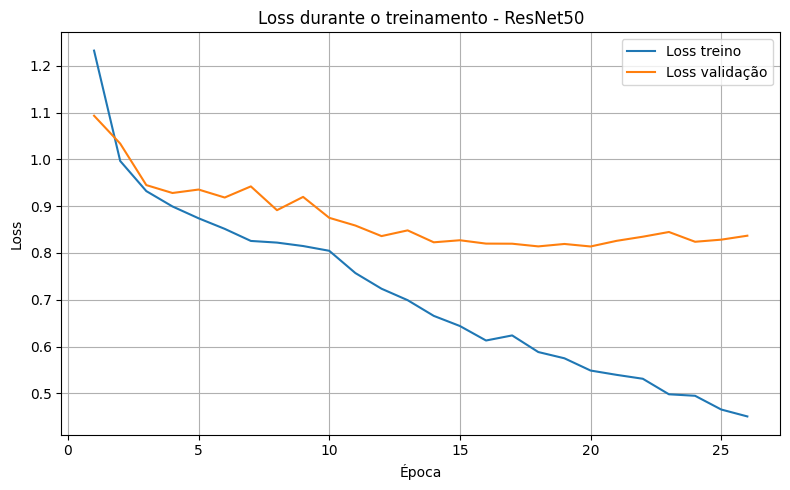

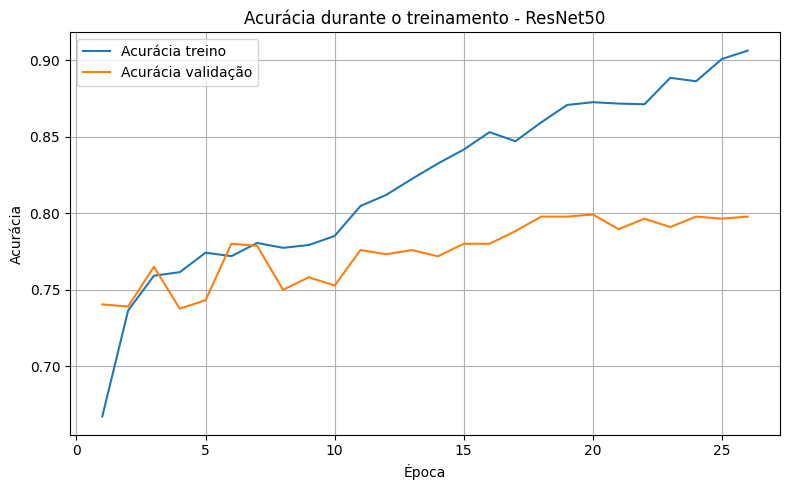

Figuras salvas em:
/home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/figures/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_loss.png
/home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/figures/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_accuracy.png


In [16]:
# CÉLULA 17 - Gerar gráficos de loss e acurácia

plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["train_loss"], label="Loss treino")
plt.plot(history_df.index + 1, history_df["val_loss"], label="Loss validação")
plt.title(f"Loss durante o treinamento - {MODEL_NAME}")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = FIGURES_DIR / f"{MODEL_OUTPUT_KEY}_loss.png"
plt.savefig(loss_fig_path, dpi=300)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["train_accuracy"], label="Acurácia treino")
plt.plot(history_df.index + 1, history_df["val_accuracy"], label="Acurácia validação")
plt.title(f"Acurácia durante o treinamento - {MODEL_NAME}")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_fig_path = FIGURES_DIR / f"{MODEL_OUTPUT_KEY}_accuracy.png"
plt.savefig(acc_fig_path, dpi=300)
plt.show()

print("Figuras salvas em:")
print(loss_fig_path)
print(acc_fig_path)

In [17]:
# CÉLULA 18 - Avaliação final no conjunto de teste

test_loss, test_accuracy, y_true, y_pred = evaluate(
    model, test_loader, criterion, device
)

print("Loss no teste:", test_loss)
print("Acurácia no teste:", test_accuracy)

Loss no teste: 0.7163949609615956
Acurácia no teste: 0.8185538881309686


In [18]:
# CÉLULA 19 - Gerar relatório de classificação

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    digits=4
)

print(report)

report_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_classification_report.txt"
report_path.write_text(report, encoding="utf-8")

print("Relatório salvo em:", report_path)

                           precision    recall  f1-score   support

          Sem retinopatia     0.9721    0.9668    0.9694       361
         Retinopatia leve     0.5747    0.6757    0.6211        74
     Retinopatia moderada     0.7550    0.7550    0.7550       200
       Retinopatia severa     0.5102    0.6410    0.5682        39
Retinopatia proliferativa     0.6579    0.4237    0.5155        59

                 accuracy                         0.8186       733
                macro avg     0.6940    0.6924    0.6858       733
             weighted avg     0.8229    0.8186    0.8179       733

Relatório salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_classification_report.txt


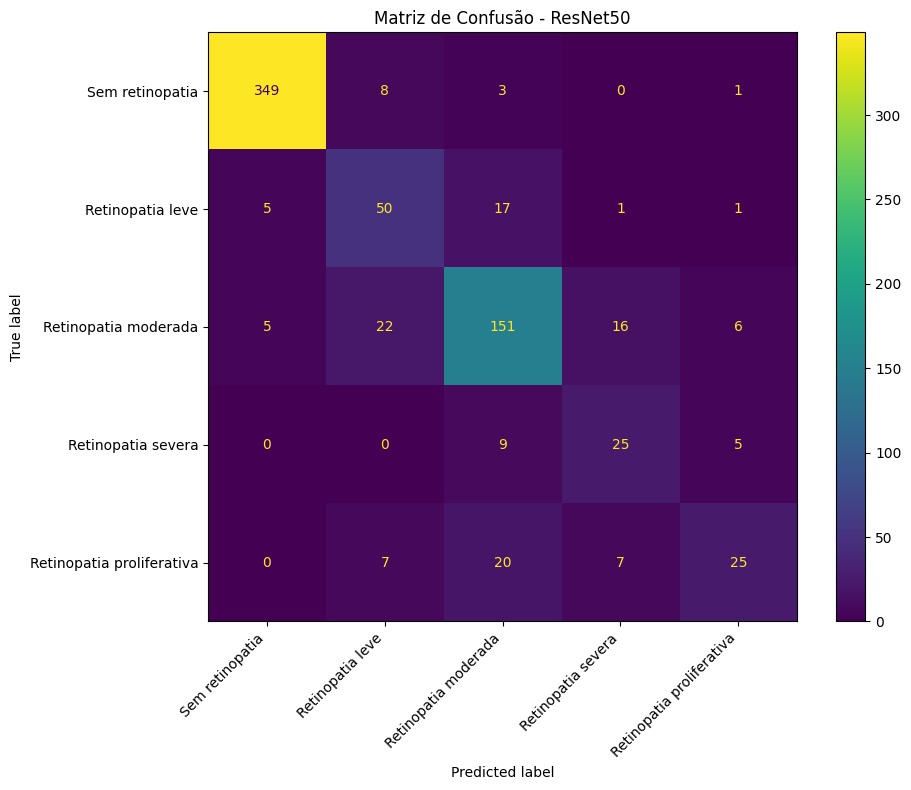

Matriz salva em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_confusion_matrix.csv
Figura salva em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/figures/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_confusion_matrix.png


In [19]:
# CÉLULA 20 - Gerar matriz de confusão

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_labels,
    columns=class_labels
)

cm_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_confusion_matrix.csv"
cm_df.to_csv(cm_path, encoding="utf-8-sig")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="viridis", values_format="d")
plt.title(f"Matriz de Confusão - {MODEL_NAME}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

cm_fig_path = FIGURES_DIR / f"{MODEL_OUTPUT_KEY}_confusion_matrix.png"
plt.savefig(cm_fig_path, dpi=300)
plt.show()

print("Matriz salva em:", cm_path)
print("Figura salva em:", cm_fig_path)

In [ ]:
# CÉLULA 21 - Salvar modelo final e resumo de métricas

final_model_path = MODEL_OUTPUT_DIR / f"{MODEL_OUTPUT_KEY}_final.pt"
torch.save(model.state_dict(), final_model_path)

summary_metrics = {
    "model": MODEL_NAME,
    "framework": "PyTorch",
    "experiment_name": EXPERIMENT_NAME,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "epochs_head_configured": EPOCHS_HEAD,
    "epochs_fine_tuning_configured": EPOCHS_FINE_TUNING,
    "epochs_completed_total": int(len(history_df)),
    "batch_size": BATCH_SIZE,
    "image_size": list(IMG_SIZE),
    "dropout_rate": DROPOUT_RATE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "persistent_workers": PERSISTENT_WORKERS,
    "class_weight_mode": CLASS_WEIGHT_MODE,
    "class_weights": class_weights,
    "loss_function": LOSS_FUNCTION,
    "focal_gamma": FOCAL_GAMMA if LOSS_FUNCTION == "focal" else None,
    "label_smoothing": LABEL_SMOOTHING if LOSS_FUNCTION == "cross_entropy" else None,
    "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
    "split_strategy": "60% treino / 20% validação / 20% teste",
    "preprocess_input": "torchvision.transforms.Normalize(mean=ImageNet, std=ImageNet)",
    "data_augmentation": {
        "Resize": list(IMG_SIZE),
        "RandomRotation": 8,
        "RandomAffine_translate": [0.03, 0.03],
        "RandomAffine_scale": [0.95, 1.05],
        "RandomHorizontalFlip": 0.5,
    },
    "run_fine_tuning": True,
    "fine_tuning_scope": FINE_TUNING_SCOPE,
    "fine_tuning_layers": (
        "layer4 + fc"
        if FINE_TUNING_SCOPE == "layer4"
        else (
            "layer3 + layer4 + fc"
            if FINE_TUNING_SCOPE == "layer3_4"
            else "layer2 + layer3 + layer4 + fc"
        )
    ),
    "head_learning_rate": HEAD_LEARNING_RATE,
    "fine_tuning_learning_rate": FINE_TUNING_LEARNING_RATE,
    "head_training_time_seconds": float(head_training_time),
    "fine_tuning_time_seconds": float(fine_tuning_time),
    "gpu_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "final_model_path": str(final_model_path),
    "best_head_checkpoint_path": str(checkpoint_head_path),
    "best_fine_checkpoint_path": str(checkpoint_fine_path),
}

summary_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_summary_metrics.json"

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=4, ensure_ascii=False)

print("Modelo final salvo em:", final_model_path)
print("Resumo salvo em:", summary_path)
summary_metrics


Modelo final salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_final.pt
Resumo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/resnet50_pytorch_gpu_resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5_summary_metrics.json


{'model': 'ResNet50',
 'framework': 'PyTorch',
 'experiment_name': 'resnet50_pytorch_gpu_v2_448_bs12_sqrt_ce_labelsmooth0015_ft_layer2_3_4_lr1e5',
 'test_loss': 0.7163949609615956,
 'test_accuracy': 0.8185538881309686,
 'epochs_head_configured': 10,
 'epochs_fine_tuning_configured': 40,
 'epochs_completed_total': 26,
 'batch_size': 12,
 'image_size': [448, 448],
 'dropout_rate': 0.3,
 'num_workers': 8,
 'pin_memory': True,
 'persistent_workers': True,
 'class_weight_mode': 'sqrt',
 'class_weights': {0: 0.6369653353298114,
  1: 1.4068686076813568,
  2: 0.8564787951515439,
  3: 1.9462607827531127,
  4: 1.5755906434433453},
 'loss_function': 'cross_entropy',
 'focal_gamma': None,
 'label_smoothing': 0.015,
 'use_weighted_sampler': False,
 'split_strategy': '60% treino / 20% validação / 20% teste',
 'preprocess_input': 'torchvision.transforms.Normalize(mean=ImageNet, std=ImageNet)',
 'data_augmentation': {'Resize': [448, 448],
  'RandomRotation': 8,
  'RandomAffine_translate': [0.03, 0.03]

: 

## Observações

Este notebook é uma cópia experimental da ResNet50 final, criada para testar um fine-tuning mais profundo sem alterar o arquivo oficial.

Use principalmente:

- **CÉLULA 03**: hiperparâmetros principais;
- **CÉLULA 14**: escopo do fine-tuning;
- **CÉLULA 21**: salvamento das métricas.

Neste teste, a ResNet50 usa `FINE_TUNING_SCOPE = "layer2_3_4"`, mantendo o restante próximo ao experimento final: `448x448`, `batch 24`, `class_weight sqrt`, `CrossEntropyLoss`, `label_smoothing 0.015` e `lr 1e-5`.

Resultado-alvo para superar a ResNet50 oficial:

- Acurácia maior que 80,35%;
- Macro F1-score maior que 66,25%.
